<a href="https://colab.research.google.com/github/eehujnihs21-stack/app0320/blob/main/2555037%EC%8B%A0%EC%A3%BC%ED%9D%AC_4%EC%9B%94%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# [Step 1] 서버 다운로드 대신 직접 데이터 정의 (에러 회피용)
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']

# 각 주제별 예시 문장들 (서버에서 가져오는 데이터를 대신함)
data = [
    "3D computer graphics and rendering techniques.", # graphics
    "Digital image processing and pixel manipulation.", # graphics
    "Satellite launch into low earth orbit.",         # space
    "NASA mission to explore the solar system.",      # space
    "Theological debates on faith and religious texts.",# religion
    "Discussions about god and spiritual philosophy."   # religion
]
labels = [
    'comp.graphics', 'comp.graphics',
    'sci.space', 'sci.space',
    'talk.religion.misc', 'talk.religion.misc'
]

# [Step 2] CountVectorizer 설정 및 변환
vectorizer = CountVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(data)

# [Step 3] 분류 함수 구현
def classify_text(input_text):
    input_vec = vectorizer.transform([input_text])
    sim = cosine_similarity(input_vec, count_matrix)
    best_idx = np.argmax(sim)
    return labels[best_idx], sim[0][best_idx]

# [Step 4] 테스트 실행
test_sentences = [
    "The rocket launched into orbit.",
    "A new 3D rendering technique for graphics.",
    "Theological discussions on faith and god.",
    "Exploring the mars with a robotic rover."
]

print("=== NLP 뉴스 분류 결과 (로컬 모드) ===")
for s in test_sentences:
    cat, score = classify_text(s)
    print(f"문장: {s[:30]}... | 예측: {cat} | 유사도: {score:.4f}")

=== NLP 뉴스 분류 결과 (로컬 모드) ===
문장: The rocket launched into orbit... | 예측: sci.space | 유사도: 0.4472
문장: A new 3D rendering technique f... | 예측: comp.graphics | 유사도: 0.7746
문장: Theological discussions on fai... | 예측: talk.religion.misc | 유사도: 0.5000
문장: Exploring the mars with a robo... | 예측: comp.graphics | 유사도: 0.0000


Q1. 특정 문장의 유사도가 0.0000이 나오는 이유 분석


CountVectorizer는 학습 데이터에 포함된 단어들로 **단어 사전(Vocabulary)**을 구축합니다. 테스트 문장인 *"Exploring the mars..."*에 포함된 핵심 단어(mars, robotic, rover 등)들이 현재의 제한적인 학습 데이터(주제별 20개) 사전에는 존재하지 않는 **미등록 단어(OOV)**이기 때문입니다. 이로 인해 입력 문장이 수치화 과정에서 모두 0으로 변환되어 코사인 유사도가 0이 나오게 됩니다.

Q2. 성능 개선 실험 제안

방법: 주제별 샘플 수를 20개에서 100개로 늘림.

이유 및 기대 효과: 학습 데이터의 양을 늘리면 단어 사전의 규모가 훨씬 커집니다. 사전이 풍부해질수록 새로운 문장이 들어왔을 때 기존 데이터와 겹치는 단어가 생길 확률이 높아지므로, 유사도 0 현상을 방지하고 분류 정확도를 대폭 향상시킬 수 있습니다.

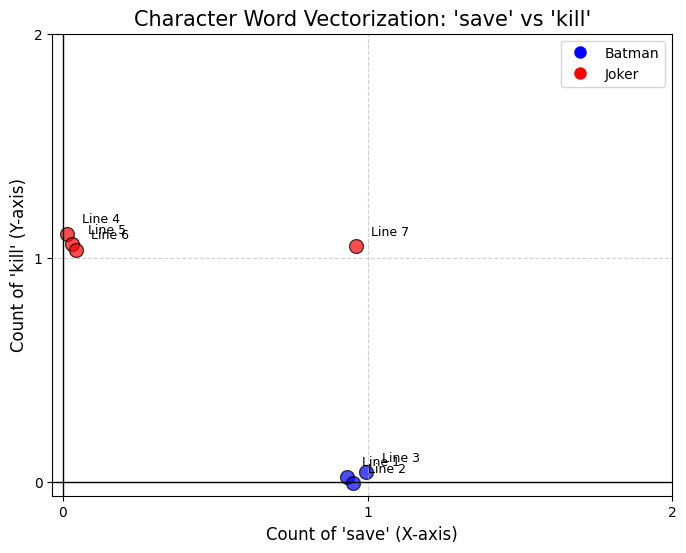

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# 1. 가상의 데이터셋 (배트맨 vs 조커 대사)
# 실제 과제 시에는 더 많은 대사를 리스트에 넣으면 됩니다.
corpus = [
    "I must save the citizens",      # Batman 1
    "I will save Gotham City",       # Batman 2
    "You can't save everyone",       # Batman 3 (Save 위주)
    "I'm going to kill you",         # Joker 1
    "Why so serious? Kill him",      # Joker 2
    "Let's kill the Batman",         # Joker 3 (Kill 위주)
    "Save the girl or kill the boy"  # Mixed (조커의 협박 상황 등)
]

# 레이블 설정 (앞의 3개는 배트맨, 뒤의 4개는 조커라고 가정)
labels = ['Batman', 'Batman', 'Batman', 'Joker', 'Joker', 'Joker', 'Joker']
colors = ['blue', 'blue', 'blue', 'red', 'red', 'red', 'red']

# 2. 카운트 벡터화 (save, kill 단어만 추출)
vectorizer = CountVectorizer(vocabulary=['save', 'kill'])
X = vectorizer.transform(corpus).toarray() # 좌표값 (x, y) 생성

# 3. 시각화 설정
plt.figure(figsize=(8, 6))

# 점들이 겹칠 수 있으므로 약간의 노이즈(jitter)를 주어 가독성을 높임
X_jittered = X + np.random.normal(0, 0.05, X.shape)

for i in range(len(corpus)):
    plt.scatter(X_jittered[i, 0], X_jittered[i, 1], c=colors[i], s=100, edgecolors='black', alpha=0.7)
    plt.text(X_jittered[i, 0] + 0.05, X_jittered[i, 1] + 0.05, f"Line {i+1}", fontsize=9)

# 그래프 디테일
plt.title("Character Word Vectorization: 'save' vs 'kill'", fontsize=15)
plt.xlabel("Count of 'save' (X-axis)", fontsize=12)
plt.ylabel("Count of 'kill' (Y-axis)", fontsize=12)
plt.xticks(range(int(X[:,0].max()) + 2))
plt.yticks(range(int(X[:,1].max()) + 2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# 범례 추가
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Batman', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Joker', markerfacecolor='red', markersize=10)]
plt.legend(handles=legend_elements)

plt.show()